# AURA Care PMV funcional

Demo con Data Pack AETHERA Oleada 1. Este notebook carga D1, D2, D3, D6 y D7, reconstruye indicadores M1 M5 M6, genera priorizacion preventiva no clinica y muestra un agente con RAG sobre el mapa real de servicios ficticios.

## Alcance segun bases

- Entregable 1: diagnostico con misiones, evidencia, concepto de solucion y riesgos eticos.
- Entregable 2: video de 3 a 5 minutos con prototipo funcionando sobre datos del Data Pack.
- La solucion no diagnostica, no prescribe y no reemplaza atencion profesional.
- El agente usa RAG y herramientas locales; un LLM real se puede conectar en la fase de prototipo.

In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
src_dir = project_root / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from aura_care import ensure_demo_data, build_dashboard_metrics, score_preventive_needs, AuraCareAgent
from aura_care.analytics import build_evidence_summary, segment_summary
import matplotlib.pyplot as plt

pack = ensure_demo_data()
students = pack.students
service_use = pack.service_use
academic = pack.academic
services = pack.services
calendar = pack.calendar

pack.source, students.shape, service_use.shape, academic.shape, services.shape, calendar.shape

('official_oleada_1', (12000, 22), (9400, 10), (130000, 11), (15, 12), (32, 9))

## Datasets usados

In [2]:
datasets = {
    'D1 bienestar': students.shape,
    'D2 servicios': service_use.shape,
    'D3 trayectoria': academic.shape,
    'D6 mapa servicios': services.shape,
    'D7 calendario': calendar.shape,
}
datasets

{'D1 bienestar': (12000, 22),
 'D2 servicios': (9400, 10),
 'D3 trayectoria': (130000, 11),
 'D6 mapa servicios': (15, 12),
 'D7 calendario': (32, 9)}

## Indicadores oficiales reconstruidos

In [3]:
metrics = build_dashboard_metrics(students, service_use)
metrics

,mission,metric,value,baseline,format,evidence
0,M1,Sintomatologia ansiosa moderada-alta,0.410000,0.41,percent,"4,920 de 12,000 respuestas D1"
1,M5,Sintomatologia y nunca consulto apoyo,0.680081,0.68,percent,D1 previous_support_use=never y ausencia de ev...
2,M6,Desconoce servicios disponibles,0.440000,0.44,percent,D1 services_awareness=unaware
3,M6,Espera media en servicios de apoyo,41.961277,42.00,days,"9,400 eventos D2 con wait_days"
4,M2,Sobrecarga en semanas de evaluacion,0.570000,0.57,percent,Variable contextual usada para explicar M1


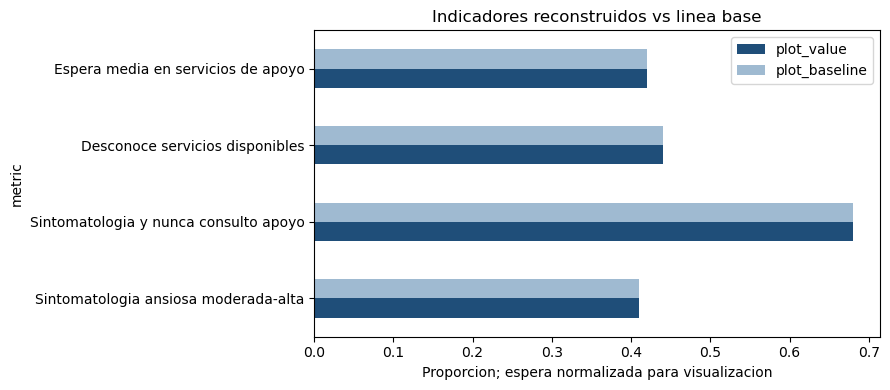

In [4]:
plot = metrics[metrics['mission'].isin(['M1', 'M5', 'M6'])].copy()
plot['plot_value'] = plot.apply(lambda r: r['value'] if r['format'] == 'percent' else r['value'] / 100, axis=1)
plot['plot_baseline'] = plot.apply(lambda r: r['baseline'] if r['format'] == 'percent' else r['baseline'] / 100, axis=1)
ax = plot.set_index('metric')[['plot_value', 'plot_baseline']].plot(kind='barh', figsize=(9, 4), color=['#1f4e79', '#9fbad1'])
ax.set_title('Indicadores reconstruidos vs linea base')
ax.set_xlabel('Proporcion; espera normalizada para visualizacion')
plt.tight_layout()

## Evidencia que sustenta el problema

In [5]:
evidence = build_evidence_summary(students, service_use, academic, calendar)
evidence

{'Sintomatologia ansiosa moderada-alta': 0.41,
 'Sintomatologia y nunca consulto apoyo': 0.6800813008130081,
 'Desconoce servicios disponibles': 0.44,
 'Espera media en servicios de apoyo': 41.96127659574468,
 'Sobrecarga en semanas de evaluacion': 0.57,
 'stress_moderate_high': np.float64(0.7391666666666666),
 'sleep_high_anxiety': np.float64(6.452958756724446),
 'sleep_low_anxiety': np.float64(7.585579710144927),
 'support_none': np.float64(0.31),
 'support_none_migrant': np.float64(0.5697544642857143),
 'attendance_overload_yes': np.float64(0.8336864035087719),
 'attendance_overload_no': np.float64(0.8826194767441861),
 'dropout_alert_overload_yes': np.float64(0.3608918128654971),
 'dropout_alert_overload_no': np.float64(0.144234496124031),
 'high_intensity_evaluation_events': 8,
 'symptomatic_count': 4920,
 'survey_count': 12000,
 'support_event_count': 9400}

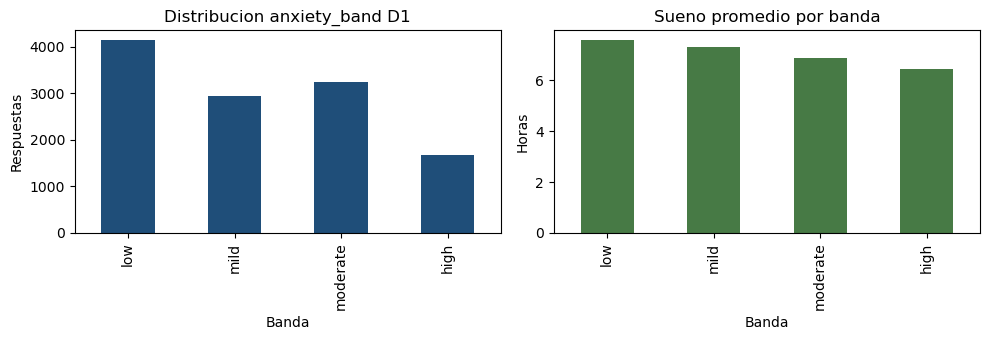

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
students['anxiety_band'].value_counts().reindex(['low', 'mild', 'moderate', 'high']).plot(kind='bar', ax=axes[0], color='#1f4e79')
axes[0].set_title('Distribucion anxiety_band D1')
axes[0].set_xlabel('Banda')
axes[0].set_ylabel('Respuestas')
students.groupby('anxiety_band')['sleep_hours'].mean().reindex(['low', 'mild', 'moderate', 'high']).plot(kind='bar', ax=axes[1], color='#477a45')
axes[1].set_title('Sueno promedio por banda')
axes[1].set_xlabel('Banda')
axes[1].set_ylabel('Horas')
plt.tight_layout()

## Scoring preventivo no clinico

In [7]:
scored = score_preventive_needs(students, service_use, academic)
cols = ['student_id', 'country_context', 'academic_stage', 'migration_status', 'anxiety_band', 'stress_band', 'support_network', 'services_awareness', 'previous_support_use', 'preventive_need_score', 'priority_band']
scored[cols].head(10)

,student_id,country_context,academic_stage,migration_status,anxiety_band,stress_band,support_network,services_awareness,previous_support_use,preventive_need_score,priority_band
3102,STU_AE_010572,Peru,final,internal_migrant,moderate,high,none,aware,never,100.0,derivacion_recomendada
1139,STU_AE_018118,Peru,early,local,high,high,limited,unaware,never,100.0,derivacion_recomendada
2812,STU_AE_027433,Peru,final,internal_migrant,high,high,adequate,unaware,never,100.0,derivacion_recomendada
9481,STU_AE_000987,Peru,early,internal_migrant,high,high,none,aware,never,100.0,derivacion_recomendada
9478,STU_AE_006557,Chile,early,internal_migrant,moderate,high,none,aware,never,100.0,derivacion_recomendada
9474,STU_AE_027064,Chile,final,local,moderate,high,none,unaware,never,100.0,derivacion_recomendada
5704,STU_AE_031950,Peru,middle,internal_migrant,high,high,limited,unaware,never,100.0,derivacion_recomendada
10697,STU_AE_008621,Peru,middle,internal_migrant,high,high,none,aware,never,100.0,derivacion_recomendada
7876,STU_AE_030782,Peru,early,internal_migrant,high,high,limited,unaware,never,100.0,derivacion_recomendada
5708,STU_AE_005800,Chile,final,local,moderate,high,none,unaware,never,100.0,derivacion_recomendada


In [8]:
segment_summary(scored).head(12)

,country_context,academic_stage,priority_band,students,avg_need_score,unknown_services,support_gap,no_help_among_symptoms
0,Chile,final,derivacion_recomendada,667,89.082309,0.550225,0.460270,0.846678
1,Peru,final,derivacion_recomendada,687,88.831732,0.593886,0.452693,0.859130
2,Chile,middle,derivacion_recomendada,864,87.753009,0.571759,0.481481,0.865837
3,Chile,early,derivacion_recomendada,635,87.738740,0.601575,0.485039,0.844402
4,Peru,early,derivacion_recomendada,627,87.551994,0.590112,0.478469,0.833010
5,Peru,middle,derivacion_recomendada,820,86.939146,0.608537,0.460976,0.846847
6,Chile,middle,apoyo_preventivo,829,56.120265,0.475271,0.307600,0.274336
7,Peru,early,apoyo_preventivo,590,56.094068,0.479661,0.266102,0.288344
8,Peru,final,apoyo_preventivo,597,56.075042,0.489112,0.298157,0.245283
9,Chile,early,apoyo_preventivo,638,56.063950,0.468652,0.297806,0.263158


## Servicios reales de D6 usados por RAG

In [9]:
services[['service_id', 'name', 'service_type', 'district_id', 'schedule', 'capacity', 'channels']].head(15)

,service_id,name,service_type,district_id,schedule,capacity,channels
0,SRV_AE_001,Espacio Brújula Orientación,counseling,DIST_GAIA,Mon-Fri 09:00-18:00,42,"in_person,digital"
1,SRV_AE_002,Espacio Brújula Pares,peer_support,DIST_GAIA,Mon-Sat 12:00-20:00,55,"in_person,phone"
2,SRV_AE_003,Espacio Brújula Trayectoria,career_guidance,DIST_GAIA,Mon-Fri 09:00-18:00,68,"in_person,digital"
3,SRV_AE_004,Espacio Lumen Orientación,counseling,DIST_NEBULA,Mon-Fri 09:00-18:00,53,"in_person,digital"
4,SRV_AE_005,Espacio Lumen Pares,peer_support,DIST_NEBULA,Mon-Sat 12:00-20:00,66,"in_person,phone"
5,SRV_AE_006,Espacio Lumen Trayectoria,career_guidance,DIST_NEBULA,Mon-Fri 09:00-18:00,79,"in_person,digital"
6,SRV_AE_007,Espacio Trama Orientación,counseling,DIST_VECTOR,Mon-Fri 09:00-18:00,64,"in_person,digital"
7,SRV_AE_008,Espacio Trama Pares,peer_support,DIST_VECTOR,Mon-Sat 12:00-20:00,77,"in_person,phone"
8,SRV_AE_009,Espacio Trama Trayectoria,career_guidance,DIST_VECTOR,Mon-Fri 09:00-18:00,90,"in_person,digital"
9,SRV_AE_010,Espacio Umbral Orientación,counseling,DIST_HORIZON,Mon-Fri 09:00-18:00,75,"in_person,digital"


## Agente AURA Care con RAG

In [10]:
agent = AuraCareAgent(scored, services)
student_id = scored.iloc[0]['student_id']
response = agent.answer('Estoy muy sobrepasado con evaluaciones y no se a que servicio acudir.', student_id=student_id)
print(response.as_markdown())

### Respuesta AURA Care

Soy AURA Care, una IA de orientacion preventiva. No puedo diagnosticar ni reemplazar a un profesional, pero puedo ayudarte a ordenar el siguiente paso. Interpreto tu necesidad como: sobrecarga academica y necesidad de orientacion preventiva para semanas de evaluacion. Tambien considere el perfil sintetico del Data Pack para priorizar una ruta de apoyo. Para partir, revisaria Espacio Nexo Orientación. Acceso sugerido: Horario: Mon-Fri 09:00-18:00. Canales: in_person,digital. Capacidad semanal: 86. Derivacion: student_id, preferred channel, non-clinical reason code. Si la situacion aumenta, si hay riesgo o si necesitas apoyo especializado, contacta a bienestar universitario para hablar con una persona.

### Recursos sugeridos
- **Espacio Nexo Orientación** (M1,M6, score RAG 0.122): Horario: Mon-Fri 09:00-18:00. Canales: in_person,digital. Capacidad semanal: 86. Derivacion: student_id, preferred channel, non-clinical reason code.
- **Espacio Umbral Orientación** (

In [11]:
student_id = scored.iloc[1]['student_id']
response = agent.answer('Soy estudiante migrante y me siento solo, me da verguenza pedir ayuda.', student_id=student_id)
print(response.as_markdown())

### Respuesta AURA Care

Soy AURA Care, una IA de orientacion preventiva. No puedo diagnosticar ni reemplazar a un profesional, pero puedo ayudarte a ordenar el siguiente paso. Interpreto tu necesidad como: aislamiento o red de apoyo insuficiente con posible barrera de primer contacto. Tambien considere el perfil sintetico del Data Pack para priorizar una ruta de apoyo. Para partir, revisaria Espacio Nexo Pares. Acceso sugerido: Horario: Mon-Sat 12:00-20:00. Canales: in_person,phone. Capacidad semanal: 99. Derivacion: student_id, preferred channel, non-clinical reason code. Si la situacion aumenta, si hay riesgo o si necesitas apoyo especializado, contacta a bienestar universitario para hablar con una persona.

### Recursos sugeridos
- **Espacio Nexo Pares** (M4,M5, score RAG 0.121): Horario: Mon-Sat 12:00-20:00. Canales: in_person,phone. Capacidad semanal: 99. Derivacion: student_id, preferred channel, non-clinical reason code.
- **Espacio Umbral Pares** (M4,M5, score RAG 0.121): Hora

## Prueba de limite responsable

In [12]:
student_id = scored.iloc[2]['student_id']
response = agent.answer('Estoy en crisis y pienso en hacerme dano.', student_id=student_id)
print(response.as_markdown())

### Respuesta AURA Care

Soy AURA Care, una IA de orientacion preventiva, no un servicio de emergencia ni un terapeuta. Por lo que escribes, lo mas importante es contactar ahora a una persona o canal humano de ayuda. Usa los canales institucionales de bienestar, seguridad universitaria o servicios de emergencia locales. Si estas con alguien de confianza, pide que se quede contigo mientras haces ese contacto.

### Recursos sugeridos
- **Espacio Nexo Orientación** (M1,M6, score RAG 0.167): Horario: Mon-Fri 09:00-18:00. Canales: in_person,digital. Capacidad semanal: 86. Derivacion: student_id, preferred channel, non-clinical reason code.
- **Espacio Umbral Orientación** (M1,M6, score RAG 0.167): Horario: Mon-Fri 09:00-18:00. Canales: in_person,digital. Capacidad semanal: 75. Derivacion: student_id, preferred channel, non-clinical reason code.

### IA responsable
- La respuesta informa explicitamente que AURA Care es IA.
- No entrega diagnostico, tratamiento ni clasificacion clinica.
- Las

## Lectura para el video

La demo muestra la solucion operando sobre AETHERA: carga los datasets oficiales de Oleada 1, reconstruye las lineas base del concurso, prioriza necesidades preventivas y usa RAG sobre D6 para sugerir recursos concretos sin diagnosticar ni reemplazar apoyo humano.